In [1]:
import pandas as pd
import numpy as np

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
!wget $data

--2026-10-02 02:05:03--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   1.41M  --.-KB/s    in 0.04s   

2026-10-02 02:05:04 (33.7 MB/s) - ‘data.csv.1’ saved [1475504/1475504]



In [3]:
df = pd.read_csv('data.csv')

In [4]:
df.head(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [7]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [8]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [9]:
strings = df.dtypes[df.dtypes == 'str'].index.tolist()

In [10]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [11]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


## Exploratory data analysis

In [12]:
for col in df.columns:
    print(col)
    print(df[col].head())
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
0    bmw
1    bmw
2    bmw
3    bmw
4    bmw
Name: make, dtype: str
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
0    1_series_m
1      1_series
2      1_series
3      1_series
4      1_series
Name: model, dtype: str
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
0    2011
1    2011
2    2011
3    2011
4    2011
Name: year, dtype: int64
[2011 2012 2013 1992 1993]
28

engine_fuel_type
0    premium_unleaded_(required)
1    premium_unleaded_(required)
2    premium_unleaded_(required)
3    premium_unleaded_(required)
4    premium_unleaded_(required)
Name: engine_fuel_type, dtype: str
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
0    335.0
1    300.0
2    300.0
3    230.0
4    230.0
Name: engine_hp,

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

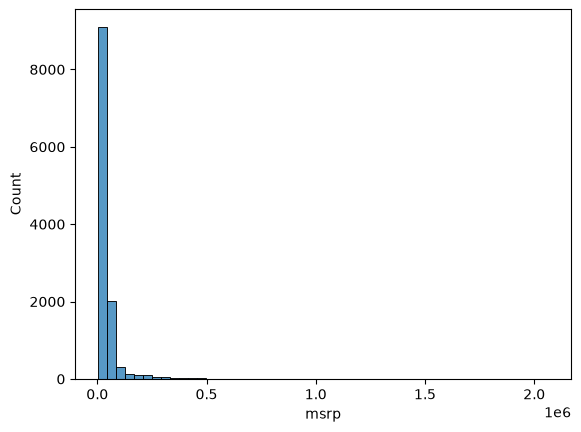

In [14]:
sns.histplot(df.msrp, bins = 50)

<Axes: xlabel='msrp', ylabel='Count'>

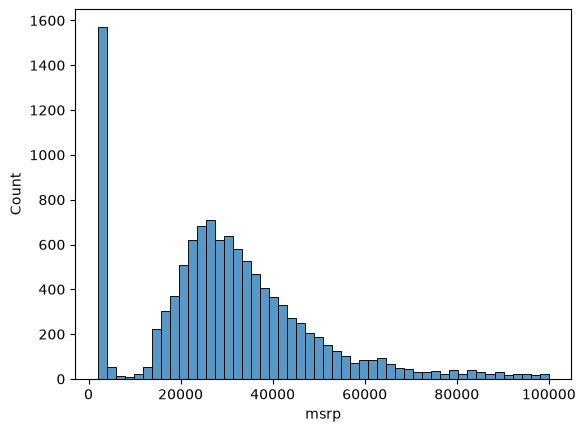

In [15]:
sns.histplot(df[df.msrp<100000].msrp, bins = 50)

In [66]:
price_logs = np.log1p(df.msrp)

In [67]:
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

In [68]:
df.msrp

0        46135
1        40650
2        36350
3        29450
4        34500
         ...  
11909    46120
11910    56670
11911    50620
11912    50920
11913    28995
Name: msrp, Length: 11914, dtype: int64

<Axes: xlabel='msrp', ylabel='Count'>

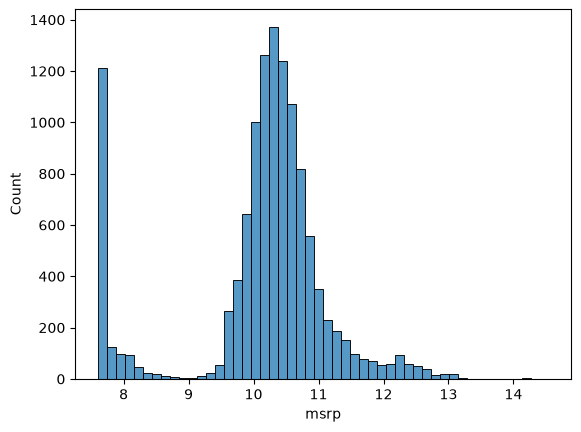

In [69]:
sns.histplot(price_logs, bins = 50)

## Missing vals

In [70]:
df.isnull().mean()

make                 0.000000
model                0.000000
year                 0.000000
engine_fuel_type     0.000252
engine_hp            0.005792
engine_cylinders     0.002518
transmission_type    0.000000
driven_wheels        0.000000
number_of_doors      0.000504
market_category      0.314084
vehicle_size         0.000000
vehicle_style        0.000000
highway_mpg          0.000000
city_mpg             0.000000
popularity           0.000000
msrp                 0.000000
dtype: float64

## Setting up validation framework

In [71]:
n = len(df)
n_val = (int(n*0.2))
n_test =(int(n*0.2))
n_train = n - n_val - n_test

In [72]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [83]:
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val+n_test]
df_train = df.iloc[n_val+n_test:]

In [84]:
idx = np.arange(n)

In [85]:
idx = np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)

In [86]:
df_train = df.iloc[idx[n_train:]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [87]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [88]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [79]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [80]:
len(y_train)

4764

## Linear Regression

In [31]:
df_train.iloc[10]

make                                      gmc
model                                  savana
year                                     2014
engine_fuel_type     flex-fuel_(unleaded/e85)
engine_hp                               310.0
engine_cylinders                          8.0
transmission_type                   automatic
driven_wheels                 all_wheel_drive
number_of_doors                           3.0
market_category                     flex_fuel
vehicle_size                          midsize
vehicle_style                   passenger_van
highway_mpg                                17
city_mpg                                   13
popularity                                549
Name: 10, dtype: object

In [32]:
xi = [453, 11, 86]

In [33]:
w0 = 7.17
w = [0.01,0.04,0.002]

In [34]:
def linear_regression(xi):
    n = len(xi)
    pred = w0

    for j in range(n):
            pred = pred + w[j] + xi[j]
    # do something
    return pred

In [35]:
linear_regression(xi)

557.222

## Linear regression Vector form

In [36]:
def dot (xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [37]:
def linear_regression(xi):
    return w0 + dot(xi,w)

In [38]:
w_new = [w0] + w

In [39]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [40]:
x1 = [1, 14, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 1, 76]


X = [x1, x2, x10]
X = np.array(X)
X



array([[   1,   14,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,    1,   76]])

In [41]:
def linear_regression(X):
    return X.dot(w_new)

In [42]:
linear_regression(X)

array([11.04 , 13.552, 11.892])

## Training a linear Regression model

In [62]:
def train_linear_regression(X, y):
    pass

In [63]:



X =[
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [162, 24, 1385],
    [245, 25, 2031],
    [166, 11, 86],
    [153, 24, 1385],
    [312, 25, 2031],
    [123, 11, 86],
]

X = np.array(X)
X


array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 162,   24, 1385],
       [ 245,   25, 2031],
       [ 166,   11,   86],
       [ 153,   24, 1385],
       [ 312,   25, 2031],
       [ 123,   11,   86]])

In [64]:
XTX = X.T.dot(X)

In [ ]:
ones = np.ones(9)

In [ ]:
X = np.column_stack([ones, X])

In [ ]:
X

## Car price baseline model

In [47]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [48]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [50]:
X_train = df_train[base].values

In [93]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    print('what')
    return w_full[0], w_full[1:]

In [94]:
X_train = df_train[base].fillna(0)

In [95]:
train_linear_regression(X_train, y_train)

what


(np.float64(7.4361128314952945),
 array([ 8.90446858e-03, -9.71331129e-02,  5.00702192e-02, -1.41250202e-02,
        -1.56882174e-05]))

y_train

In [96]:
y_train

array([10.19936098, 10.90872279,  9.72770457, ..., 10.27852782,
       10.00789261, 10.40414162], shape=(4764,))

In [97]:
w0, w = train_linear_regression(X_train, y_train)

what


In [98]:
y_pred = w0 + X_train.dot(w)

In [99]:
y_pred

0        9.790126
1       10.325164
2        9.818824
3       10.838172
4        9.896906
          ...    
4759     9.330118
4760     9.704947
4761     9.940062
4762    10.227486
4763    10.192213
Length: 4764, dtype: float64

<Axes: ylabel='Count'>

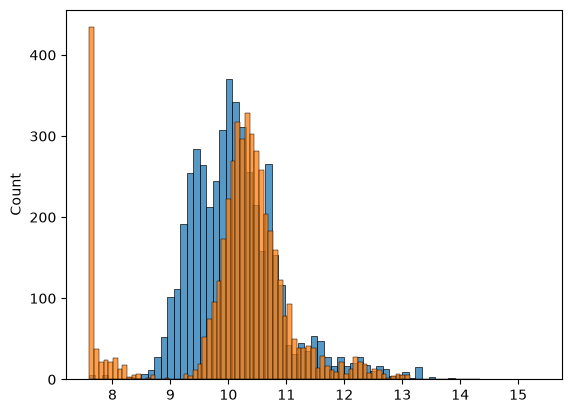

In [100]:
sns.histplot(y_pred)
sns.histplot(y_train)

## RMSE

In [102]:
def rmse(y, y_pred):
    error = y-y_pred
    se = error **2
    mse = se.mean()
    return np.sqrt(mse)

In [103]:
rmse(y_train, y_pred)

np.float64(0.7415514275559719)

## model validation

In [124]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [125]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

what


np.float64(0.7517221959226251)

In [126]:
X_train

array([[2.000e+02, 4.000e+00, 2.500e+01, 1.900e+01, 1.385e+03],
       [2.410e+02, 4.000e+00, 2.900e+01, 2.200e+01, 6.170e+02],
       [1.600e+02, 4.000e+00, 3.600e+01, 2.600e+01, 5.657e+03],
       ...,
       [2.500e+02, 6.000e+00, 2.200e+01, 1.500e+01, 1.851e+03],
       [1.740e+02, 4.000e+00, 4.200e+01, 3.100e+01, 2.202e+03],
       [2.560e+02, 6.000e+00, 2.700e+01, 2.000e+01, 6.400e+02]],
      shape=(4764, 5))

In [107]:
y_val

array([10.19936098, 10.90872279,  9.72770457, ..., 11.21756062,
        9.77542688, 10.1924563 ], shape=(2382,))

## Simple feature engineering

In [127]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base + ['age']
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [128]:
X_train = prepare_X(df_train)

In [129]:
X_train

array([[2.000e+02, 4.000e+00, 2.500e+01, 1.900e+01, 1.385e+03, 2.000e+00],
       [2.410e+02, 4.000e+00, 2.900e+01, 2.200e+01, 6.170e+02, 0.000e+00],
       [1.600e+02, 4.000e+00, 3.600e+01, 2.600e+01, 5.657e+03, 0.000e+00],
       ...,
       [2.500e+02, 6.000e+00, 2.200e+01, 1.500e+01, 1.851e+03, 1.100e+01],
       [1.740e+02, 4.000e+00, 4.200e+01, 3.100e+01, 2.202e+03, 1.000e+00],
       [2.560e+02, 6.000e+00, 2.700e+01, 2.000e+01, 6.400e+02, 2.000e+00]],
      shape=(4764, 6))

In [130]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

what


np.float64(0.5162117360740229)

<Axes: ylabel='Count'>

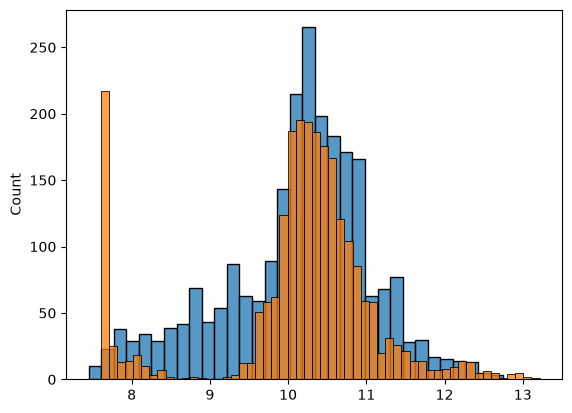

In [131]:
sns.histplot(y_pred)
sns.histplot(y_val)

## Categorical Features


In [132]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp,age
0,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885,2
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650,0
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775,0
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600,1
4,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052,19
4760,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995,3
4761,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100,11
4762,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200,1


In [134]:
for v in [2, 3, 4]:
    df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')

In [137]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year    
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [141]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

what


np.float64(49.039575083757526)

## Model tuning